## Questions
 1. Does a higher unemployment rate change since the last election increase the likelihood that a state switches its winning party?
 2. Does the relationship between a state's unemployment rate and its partisan lean (P.S. Score) strengthen or weaken over time?


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

In [2]:
##Script(s) used to analyze data and/or generate associated visualizations Analysis results and/or visualizations Documentation describing steps used to analyze or visualize data
import pandas as pd
df = pd.read_csv('fused.csv')
df

,Unnamed: 0,Year,State,Region,Democratic %,Republican %,P.S.,P.S. Score,National Winner,State Winner,ElectionYear_Unemployment,Change_Since_Last_Election
0,0,1976,Alabama,South,55.7,42.6,D+,11.23,Carter (D),Democrat,7.0,NaN
1,1,1980,Alabama,South,47.4,48.8,D+,9.26,Reagan (R),Democrat,9.4,2.4
2,2,1984,Alabama,South,38.3,60.5,R+,-4.19,Reagan (R),Republican,10.5,1.1
3,3,1988,Alabama,South,39.9,59.2,R+,-11.69,Bush H.W. (R),Republican,7.3,-3.2
4,4,1992,Alabama,South,40.9,47.6,R+,-14.55,Clinton (D),Republican,7.5,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...
645,645,2008,Wyoming,West,32.5,64.8,R+,-40.50,Obama (D),Republican,3.6,-0.1
646,646,2012,Wyoming,West,27.8,68.6,R+,-46.25,Obama (D),Republican,5.1,1.5
647,647,2016,Wyoming,West,21.9,68.2,R+,-53.64,Trump (R),Republican,5.1,0.0
648,648,2020,Wyoming,West,26.6,69.9,R+,-49.50,Biden (D),Republican,5.5,0.4


In [3]:
df.describe()

,Unnamed: 0,Year,Democratic %,Republican %,P.S. Score,ElectionYear_Unemployment,Change_Since_Last_Election
count,650.00000,650.000000,650.000000,650.000000,650.000000,650.000000,600.000000
mean,324.50000,2000.000000,45.063385,49.939385,-4.715569,5.766615,-0.268000
std,187.78312,14.978156,9.003879,9.699587,17.143247,1.904316,1.961263
min,0.00000,1976.000000,20.600000,26.600000,-53.640000,1.900000,-7.500000
25%,162.25000,1988.000000,38.700000,42.825000,-16.450000,4.300000,-1.600000
50%,324.50000,2000.000000,44.900000,49.700000,-3.400000,5.400000,-0.200000
75%,486.75000,2012.000000,51.275000,57.675000,7.752500,7.000000,1.000000
max,649.00000,2024.000000,71.800000,74.500000,39.480000,14.300000,7.800000


In [4]:
# Previous election's winner for each state (shift within group)
df['Prev_Winner'] = df.groupby('State')['State Winner'].shift(1)

# 1 = switched, 0 = stayed, NaN = first election (1976)
df['switched'] = (df['State Winner'] != df['Prev_Winner']).astype(float)
df.loc[df['Prev_Winner'].isna(), 'switched'] = np.nan

# Summary
print('=== Switching Summary (all years) ===')
print(df['switched'].value_counts(dropna=False).rename({1.0: 'Switched', 0.0: 'Stayed', np.nan: '1976 (NaN)'}))

# Preview switched states
print('\n=== Sample switched rows ===')
df[df['switched'] == 1][['Year','State','Prev_Winner','State Winner',
                          'ElectionYear_Unemployment','Change_Since_Last_Election']].head(12)

=== Switching Summary (all years) ===
switched
Stayed      529
Switched     71
NaN          50
Name: count, dtype: int64

=== Sample switched rows ===


,Year,State,Prev_Winner,State Winner,ElectionYear_Unemployment,Change_Since_Last_Election
2,1984,Alabama,Democrat,Republican,10.5,1.1
41,1984,Arkansas,Democrat,Republican,8.4,0.3
43,1992,Arkansas,Republican,Democrat,6.6,-0.9
45,2000,Arkansas,Democrat,Republican,4.2,-1.0
54,1984,California,Republican,Democrat,7.5,0.4
73,2008,Colorado,Republican,Democrat,5.7,0.3
81,1988,Connecticut,Republican,Democrat,3.0,-1.6
93,1984,Delaware,Democrat,Republican,5.9,-1.8
95,1992,Delaware,Republican,Democrat,5.1,2.0
105,1980,Florida,Democrat,Republican,6.1,-3.0


In [5]:
df['switched']

0      NaN
1      0.0
2      1.0
3      0.0
4      0.0
      ... 
645    0.0
646    0.0
647    0.0
648    0.0
649    0.0
Name: switched, Length: 650, dtype: float64

In [6]:

df_work = df.dropna(subset=['Change_Since_Last_Election', 'switched']).copy()
df_work['switched'] = df_work['switched'].astype(int)

print(f'Working rows (1980–2024): {len(df_work)}')
print(f'Switch rate: {df_work["switched"].mean():.1%} of state-elections')
df_work[['Year','State','State Winner','switched',
          'ElectionYear_Unemployment','Change_Since_Last_Election']].head(10)

Working rows (1980–2024): 600
Switch rate: 11.8% of state-elections


,Year,State,State Winner,switched,ElectionYear_Unemployment,Change_Since_Last_Election
1,1980,Alabama,Democrat,0,9.4,2.4
2,1984,Alabama,Republican,1,10.5,1.1
3,1988,Alabama,Republican,0,7.3,-3.2
4,1992,Alabama,Republican,0,7.5,0.2
5,1996,Alabama,Republican,0,5.1,-2.4
6,2000,Alabama,Republican,0,4.6,-0.5
7,2004,Alabama,Republican,0,5.2,0.6
8,2008,Alabama,Republican,0,7.2,2.0
9,2012,Alabama,Republican,0,7.8,0.6
10,2016,Alabama,Republican,0,5.7,-2.1


In [7]:
switched_vals = df_work[df_work['switched'] == 1]['Change_Since_Last_Election']
stable_vals   = df_work[df_work['switched'] == 0]['Change_Since_Last_Election']

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np

# ── Prepare data ──────────────────────────────────────────
X = df_work[['Change_Since_Last_Election', 'ElectionYear_Unemployment']]
y = df_work['switched']

# ── Fit model ─────────────────────────────────────────────
model = LogisticRegression()
model.fit(X, y)

# ── Results ───────────────────────────────────────────────
print("Coefficients:")
for name, coef in zip(X.columns, model.coef_[0]):
    print(f"  {name}: {coef:.4f}  (odds ratio: {np.exp(coef):.4f})")

print(f"\nIntercept: {model.intercept_[0]:.4f}")
print(f"\nModel Accuracy: {model.score(X, y):.2%}")
print("\nClassification Report:")
print(classification_report(y, model.predict(X)))

Coefficients:
  Change_Since_Last_Election: -0.0586  (odds ratio: 0.9431)
  ElectionYear_Unemployment: 0.1949  (odds ratio: 1.2152)

Intercept: -3.1671

Model Accuracy: 88.17%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       529
           1       0.00      0.00      0.00        71

    accuracy                           0.88       600
   macro avg       0.44      0.50      0.47       600
weighted avg       0.78      0.88      0.83       600



c:\Users\temil\OneDrive\Desktop\deela\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\temil\OneDrive\Desktop\deela\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\temil\OneDrive\Desktop\deela\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

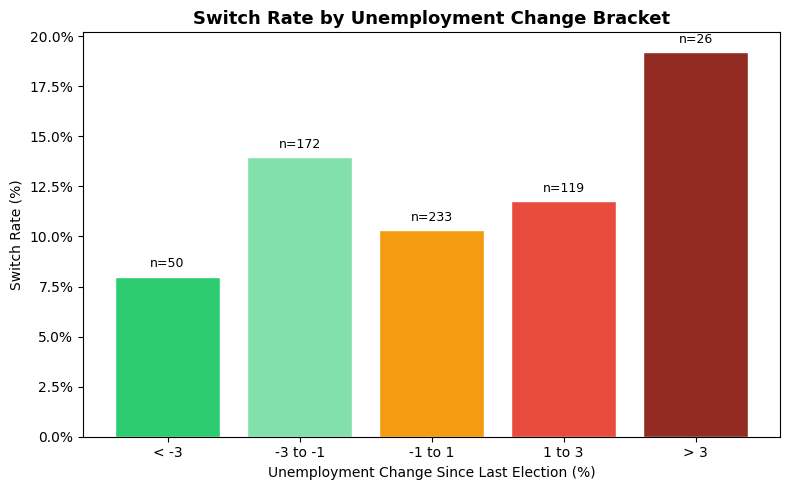

In [ ]:
# ── FIG 1: Switch probability by unemployment-change bracket ──────────────────
df_work['unemp_bin'] = pd.cut(df_work['Change_Since_Last_Election'],
                               bins=[-8, -3, -1, 1, 3, 8],
                               labels=['< -3', '-3 to -1', '-1 to 1', '1 to 3', '> 3'])
bin_rates = df_work.groupby('unemp_bin', observed=True)['switched'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#82e0aa', '#f39c12', '#e74c3c', '#922b21']
bars = ax.bar(bin_rates.index, bin_rates['mean'] * 100, color=colors, edgecolor='white')
for bar, cnt in zip(bars, bin_rates['count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'n={cnt}', ha='center', va='bottom', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Switch Rate by Unemployment Change Bracket', fontsize=13, fontweight='bold')
ax.set_xlabel('Unemployment Change Since Last Election (%)')
ax.set_ylabel('Switch Rate (%)')
plt.tight_layout()
plt.show()

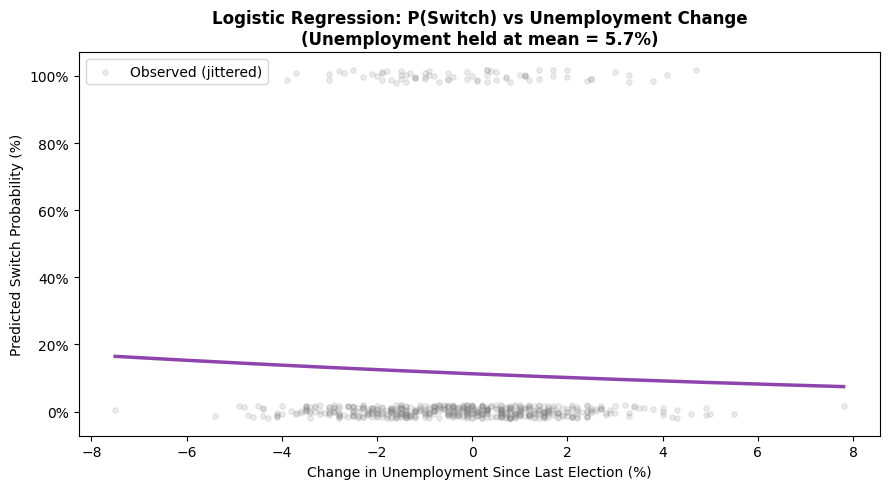

In [ ]:
# ── FIG 2: Logistic regression probability curve ──────────────────────────────
from sklearn.linear_model import LogisticRegression

X = df_work[['Change_Since_Last_Election', 'ElectionYear_Unemployment']]
y = df_work['switched']
model = LogisticRegression()
model.fit(X, y)

mean_unemp = df_work['ElectionYear_Unemployment'].mean()
x_range = np.linspace(df_work['Change_Since_Last_Election'].min(),
                      df_work['Change_Since_Last_Election'].max(), 200)
X_pred = pd.DataFrame({'Change_Since_Last_Election': x_range,
                        'ElectionYear_Unemployment': mean_unemp})
prob = model.predict_proba(X_pred)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_range, prob * 100, color='#8e44ad', linewidth=2.5)
ax.scatter(df_work['Change_Since_Last_Election'],
           df_work['switched'] * 100 + np.random.uniform(-2, 2, len(df_work)),
           alpha=0.15, color='gray', s=15, label='Observed (jittered)')
ax.set_title(f'Logistic Regression: P(Switch) vs Unemployment Change\n'
             f'(Unemployment held at mean = {mean_unemp:.1f}%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Change in Unemployment Since Last Election (%)')
ax.set_ylabel('Predicted Switch Probability (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
##2 analysis 
# Correlation per election year
years = sorted(df['Year'].unique())
results = []

for year in years:
    sub = df[df['Year'] == year].dropna(subset=['ElectionYear_Unemployment','P.S. Score'])
    if len(sub) > 5:
        r, p = stats.pearsonr(sub['ElectionYear_Unemployment'], sub['P.S. Score'])
        results.append({'Year': year, 'r': r, 'p': p, 'n': len(sub)})

corr_df = pd.DataFrame(results)
corr_df['significant'] = corr_df['p'] < 0.05

print('=== Pearson r: Unemployment vs P.S. Score per election year ===')
print(f'  (Positive r = higher unemployment → more Democratic lean)')
print(f'  (Negative r = higher unemployment → more Republican lean)')
print()
print(corr_df[['Year','r','p','significant']].to_string(index=False))

=== Pearson r: Unemployment vs P.S. Score per election year ===
  (Positive r = higher unemployment → more Democratic lean)
  (Negative r = higher unemployment → more Republican lean)

 Year         r        p  significant
 1976  0.194459 0.175987        False
 1980  0.337300 0.016602         True
 1984  0.132619 0.358566        False
 1988 -0.148183 0.304424        False
 1992  0.415253 0.002711         True
 1996  0.239803 0.093474        False
 2000 -0.109982 0.447057        False
 2004  0.005859 0.967788        False
 2008  0.233263 0.103042        False
 2012  0.307167 0.030021         True
 2016 -0.040136 0.781982        False
 2020  0.504834 0.000185         True
 2024  0.117271 0.417330        False


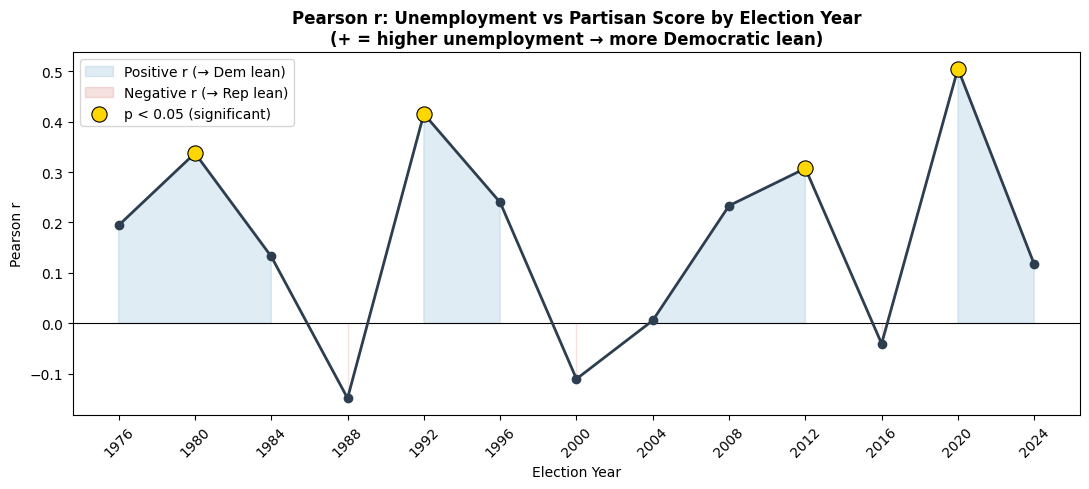

In [ ]:
# ── FIG 3: Pearson r over time with significance markers ──────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(corr_df['Year'], corr_df['r'], 0,
                where=corr_df['r'] > 0, alpha=0.15, color='#2980b9',
                label='Positive r (→ Dem lean)')
ax.fill_between(corr_df['Year'], corr_df['r'], 0,
                where=corr_df['r'] < 0, alpha=0.15, color='#c0392b',
                label='Negative r (→ Rep lean)')
ax.plot(corr_df['Year'], corr_df['r'], color='#2c3e50', linewidth=2, marker='o')

sig = corr_df[corr_df['significant']]
ax.scatter(sig['Year'], sig['r'], color='gold', s=120, zorder=5,
           edgecolors='black', linewidth=0.8, label='p < 0.05 (significant)')

ax.set_title('Pearson r: Unemployment vs Partisan Score by Election Year\n'
             '(+ = higher unemployment → more Democratic lean)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Election Year')
ax.set_ylabel('Pearson r')
ax.set_xticks(corr_df['Year'])
ax.set_xticklabels(corr_df['Year'], rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

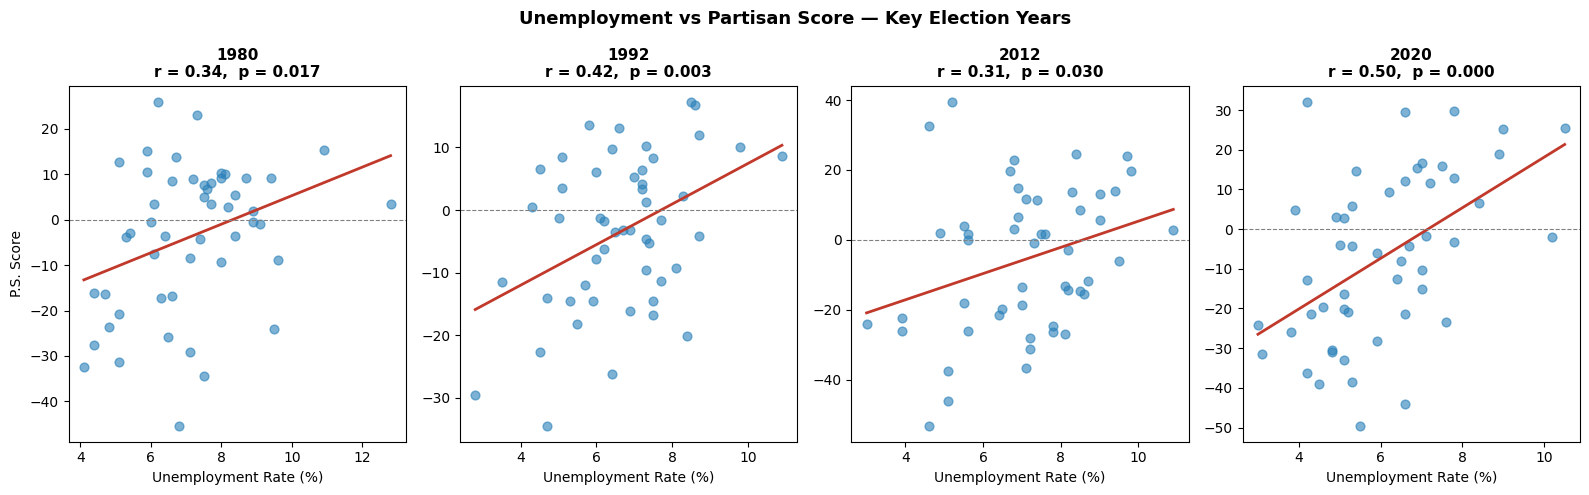

In [ ]:
# ── FIG 4: Scatter subplots for 4 key years ───────────────────────────────────
key_years = [1980, 1992, 2012, 2020]
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

for ax, year in zip(axes, key_years):
    sub = df[df['Year'] == year].dropna(subset=['ElectionYear_Unemployment', 'P.S. Score'])
    r, p = stats.pearsonr(sub['ElectionYear_Unemployment'], sub['P.S. Score'])
    m, b = np.polyfit(sub['ElectionYear_Unemployment'], sub['P.S. Score'], 1)
    x_fit = np.linspace(sub['ElectionYear_Unemployment'].min(),
                        sub['ElectionYear_Unemployment'].max(), 100)
    ax.scatter(sub['ElectionYear_Unemployment'], sub['P.S. Score'],
               alpha=0.6, color='#2980b9', s=40)
    ax.plot(x_fit, m * x_fit + b, color='#c0392b', linewidth=2)
    ax.set_title(f'{year}\nr = {r:.2f},  p = {p:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Unemployment Rate (%)')
    if year == key_years[0]:
        ax.set_ylabel('P.S. Score')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

fig.suptitle('Unemployment vs Partisan Score — Key Election Years',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()